<a href="https://colab.research.google.com/github/Dipu1764/Superstore-Sales-Analysis---Project/blob/DATA/Superstore_Sales_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Summary


**📊 Superstore Sales Analysis - Project**

This project involves analyzing and visualizing the Superstore dataset using Python, with the goal of answering 30 scenario-based business questions. The primary tools used include Pandas for data manipulation, Matplotlib and Seaborn for visualizations.

**✅ Objectives:**

Perform exploratory data analysis (EDA) on sales, profit, discount, order processing, shipping, and customer behavior.

Visualize trends and relationships to support business decision-making.

Generate insights using charts like bar plots, line charts, pie charts, scatter plots, and box plots.

**🛠️ Tools & Libraries:**

Google Colab – cloud-based Python environment

Pandas – data manipulation

Matplotlib & Seaborn – data visualization

Excel – Superstore dataset input

**📌 Key Insights Uncovered:**

Top Product Categories – Identified most profitable and high-selling categories.

Time-based Trends – Monthly sales, order trends, and delivery times analyzed.

Customer Analysis – Purchase behavior and segment performance examined.

Geographical Insights – Regional sales, profit contributions, and return rates visualized.

Discount & Profit Relationship – Impact of discounts on profitability studied.

Shipping & Processing – Evaluated average shipping time and preferred modes.

Market-wise & Year-wise Comparison – Distribution of sales across markets and years.

**📁 Deliverables:**

Fully annotated Python notebook in Google Colab.

Clean, well-labeled visualizations for each question.

Calculated fields (e.g., shipping time, profit margin).

Logical flow and organization of each question and its answer.

# Tableau link

Tableau link is here ------ https://drive.google.com/file/d/18YMs6Y5dY9QffpX9W8ABOMBnZCA6Vm_z/view?usp=drive_link

# All chart start from here

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up notebook visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
df = pd.read_excel("Sample - Superstore.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

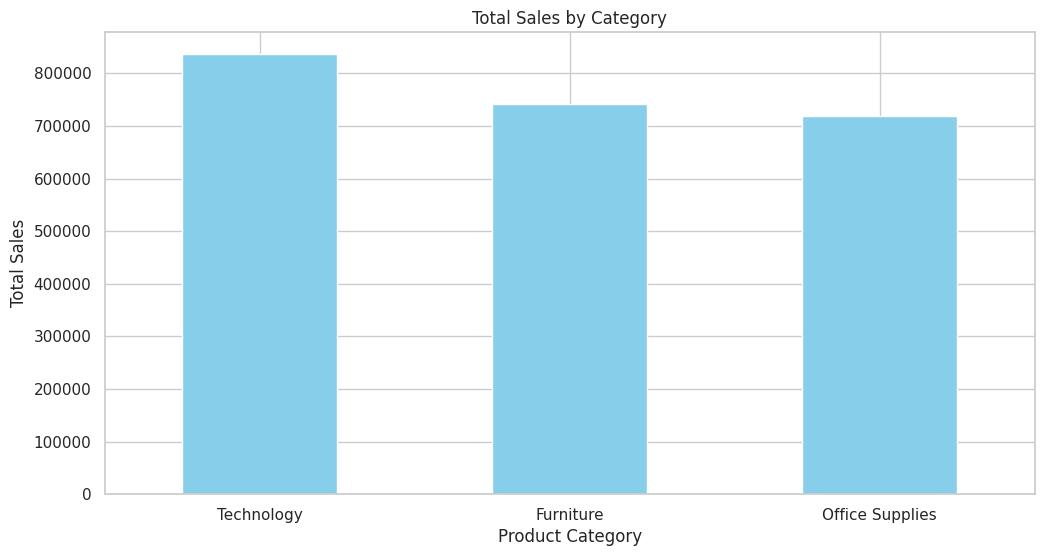

In [6]:
# Preview data
df.head()

# ------------------------------------------------------------
# Question 1: Which product categories have the highest total sales?
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', title='Total Sales by Category', color='skyblue')
plt.ylabel('Total Sales')
plt.xlabel('Product Category')
plt.xticks(rotation=0)
plt.show()

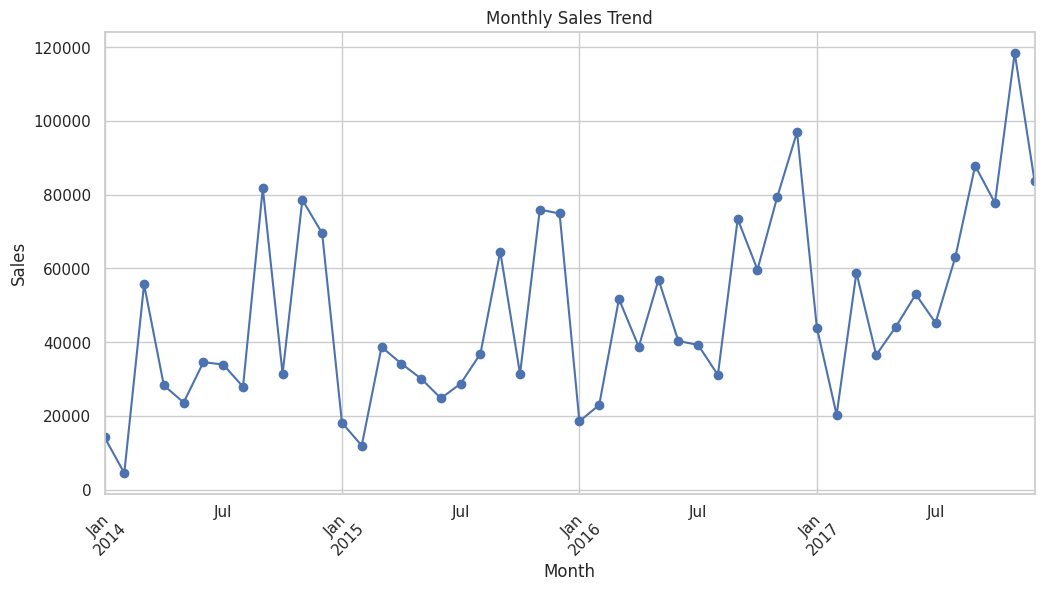

In [7]:
# Question 2: How do the monthly sales amounts change over the course of a year?
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.plot(marker='o', title='Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

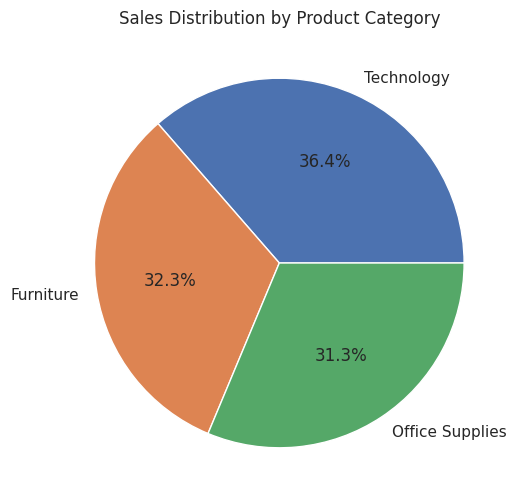

In [8]:
# Question 3: How is the total sales amount distributed among different product categories?
category_sales.plot.pie(autopct='%1.1f%%', title='Sales Distribution by Product Category')
plt.ylabel('')
plt.show()

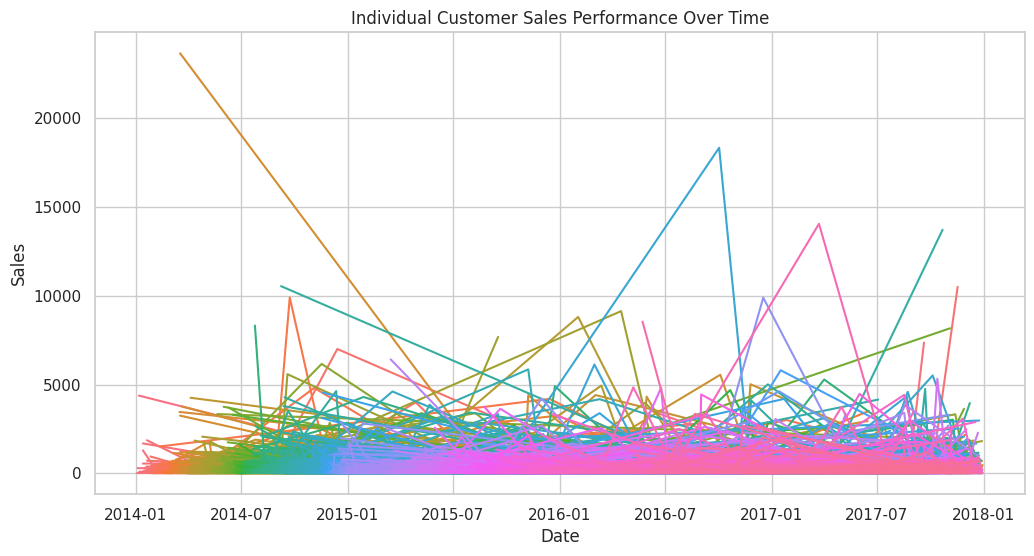

In [9]:
# Question 4: Can we analyze the sales performance of individual customers over time?
customer_sales = df.groupby(['Order Date', 'Customer Name'])['Sales'].sum().reset_index()
sns.lineplot(data=customer_sales, x='Order Date', y='Sales', hue='Customer Name', legend=False)
plt.title('Individual Customer Sales Performance Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

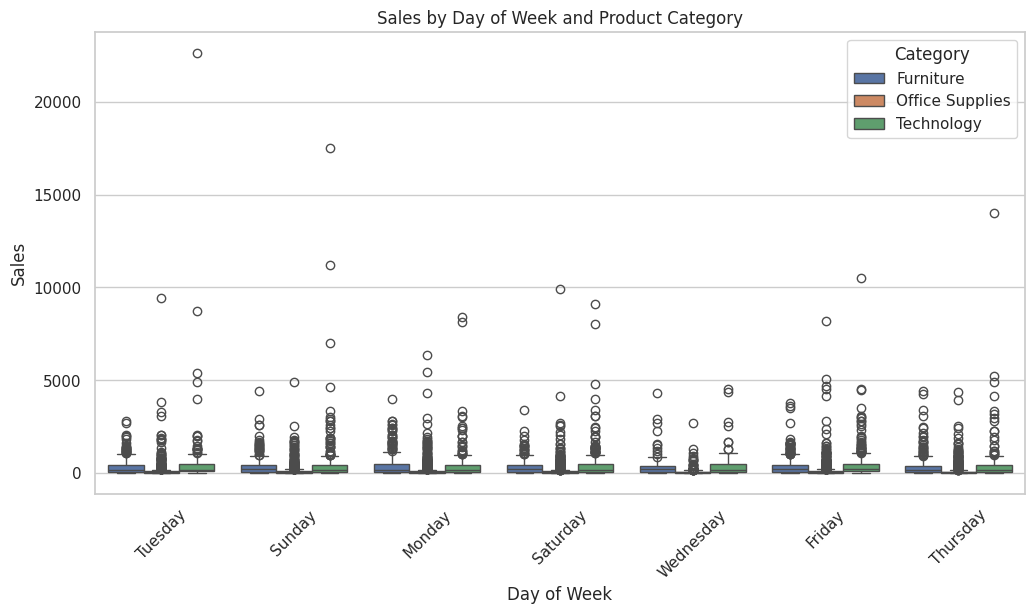

In [10]:
# Question 5: How do sales vary based on different days of the week and product categories?
df['Day of Week'] = df['Order Date'].dt.day_name()
sns.boxplot(data=df, x='Day of Week', y='Sales', hue='Category')
plt.title('Sales by Day of Week and Product Category')
plt.xticks(rotation=45)
plt.ylabel('Sales')
plt.xlabel('Day of Week')
plt.show()

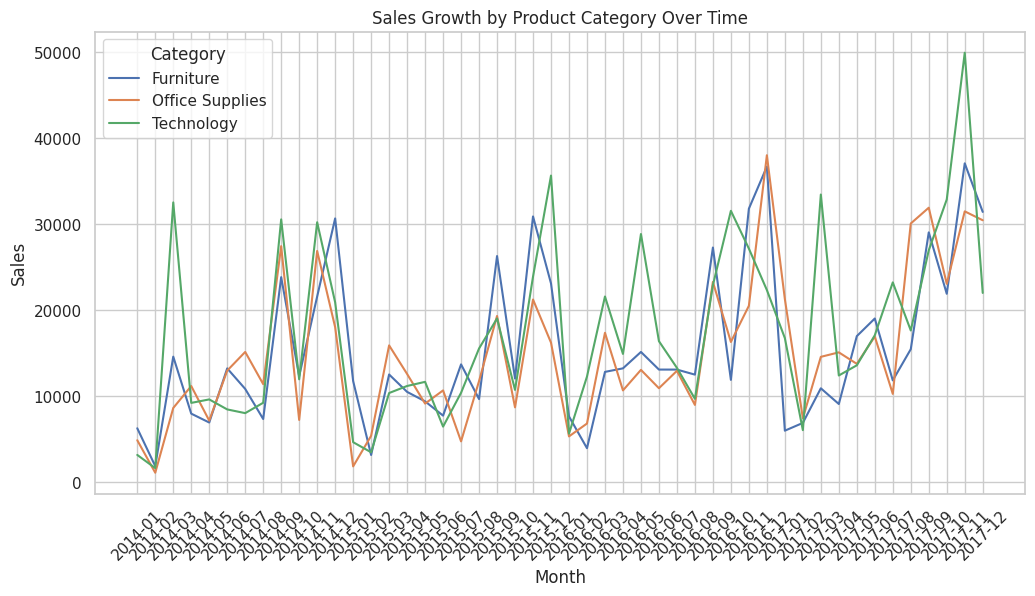

In [11]:
# Question 6: Can we visualise the sales growth of different product categories over time?
df['YearMonth'] = df['Order Date'].dt.to_period('M')
category_monthly = df.groupby(['YearMonth', 'Category'])['Sales'].sum().reset_index()
category_monthly['YearMonth'] = category_monthly['YearMonth'].astype(str)
sns.lineplot(data=category_monthly, x='YearMonth', y='Sales', hue='Category')
plt.title('Sales Growth by Product Category Over Time')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

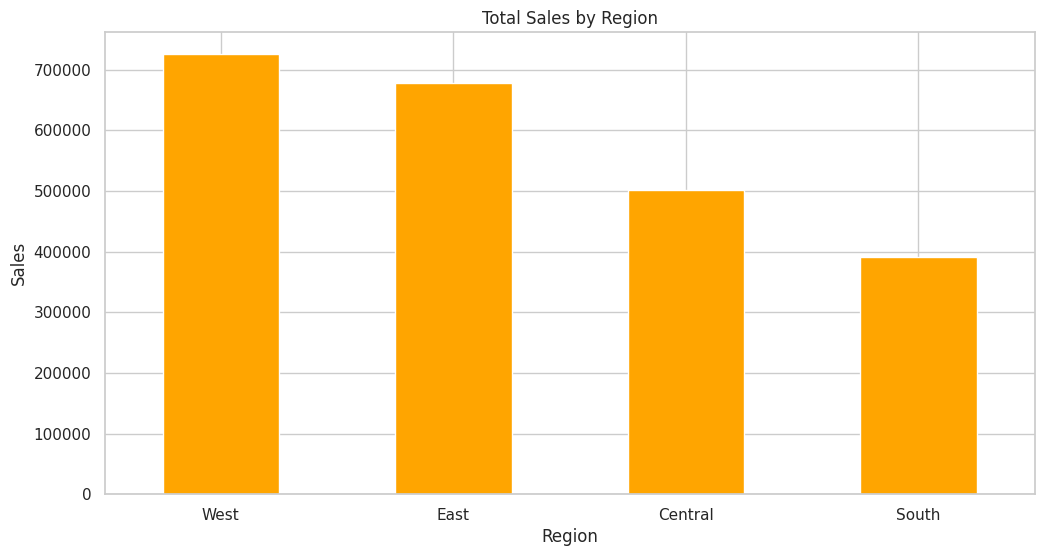

In [12]:
# Question 7: How does the sales distribution vary across different regions?
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='orange', title='Total Sales by Region')
plt.ylabel('Sales')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.show()


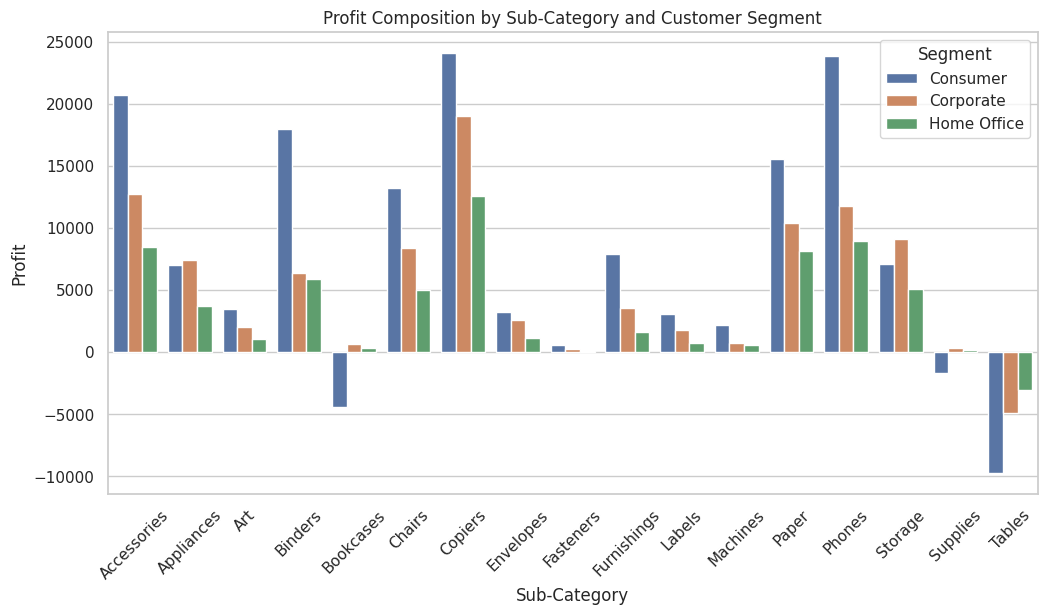

In [13]:
# Question 8: Can we visualise the composition of profits across subcategories and customer segments?
subcategory_segment_profit = df.groupby(['Sub-Category', 'Segment'])['Profit'].sum().reset_index()
sns.barplot(data=subcategory_segment_profit, x='Sub-Category', y='Profit', hue='Segment')
plt.title('Profit Composition by Sub-Category and Customer Segment')
plt.xticks(rotation=45)
plt.show()

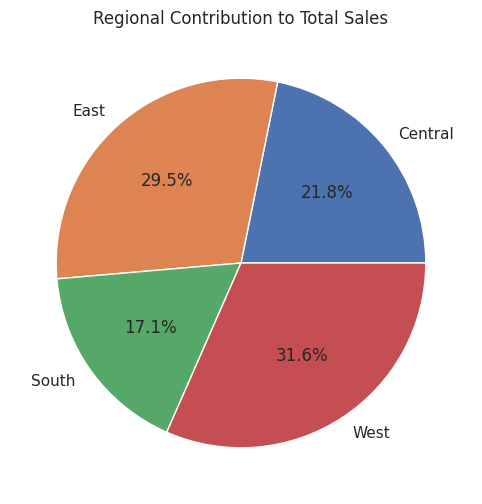

In [14]:
# Question 9: What is the percentage contribution of each region to the overall sales?
region_pct = df.groupby('Region')['Sales'].sum()
region_pct.plot.pie(autopct='%1.1f%%', title='Regional Contribution to Total Sales')
plt.ylabel('')
plt.show()

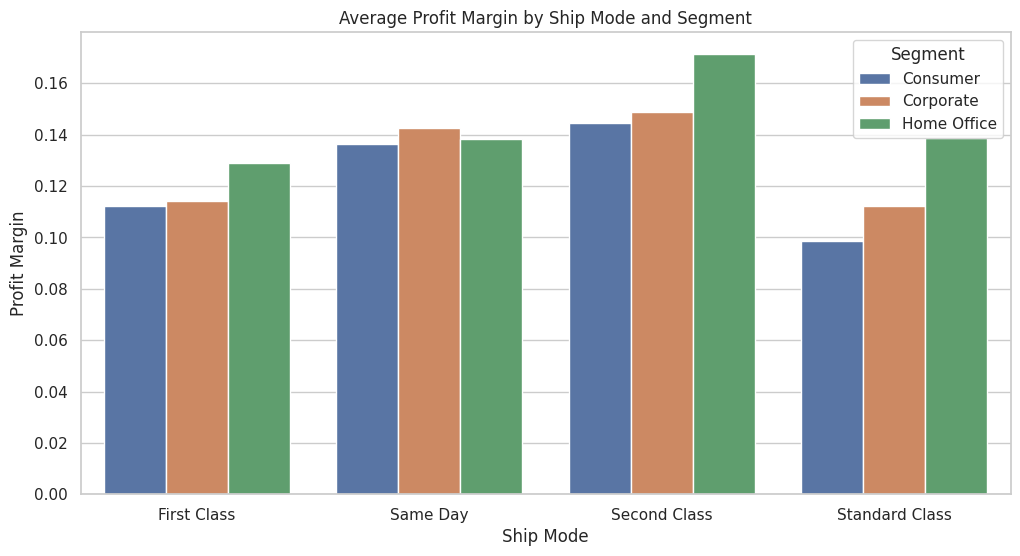

In [15]:
# Question 10: Can we visualise the profit margins associated with different shipping modes and customer segments?
df['Profit Margin'] = df['Profit'] / df['Sales']
margin_data = df.groupby(['Ship Mode', 'Segment'])['Profit Margin'].mean().reset_index()
sns.barplot(data=margin_data, x='Ship Mode', y='Profit Margin', hue='Segment')
plt.title('Average Profit Margin by Ship Mode and Segment')
plt.xticks(rotation=0)
plt.show()

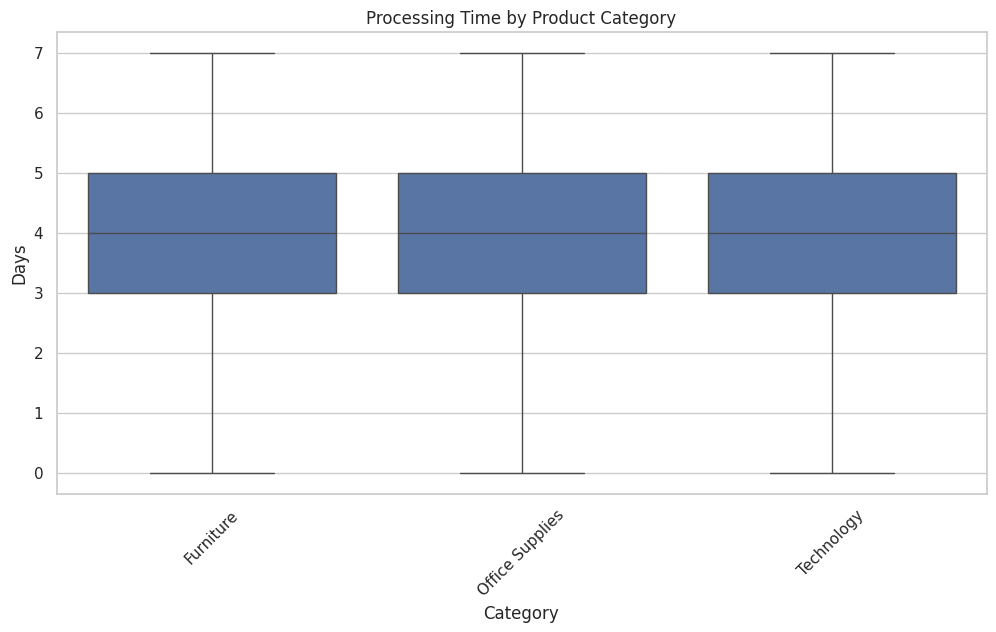

In [16]:
# Question 11: How long does it take to process orders for different product categories?
df['Processing Time'] = (df['Ship Date'] - df['Order Date']).dt.days
sns.boxplot(data=df, x='Category', y='Processing Time')
plt.title('Processing Time by Product Category')
plt.xticks(rotation=45)
plt.ylabel('Days')
plt.show()

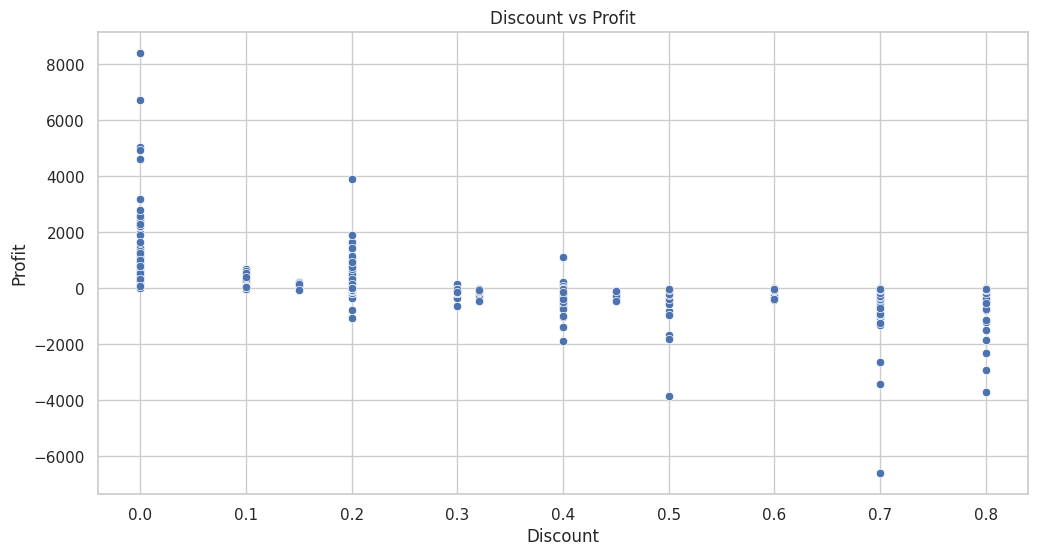

In [17]:
# Question 12: How do discounts affect overall profit?
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

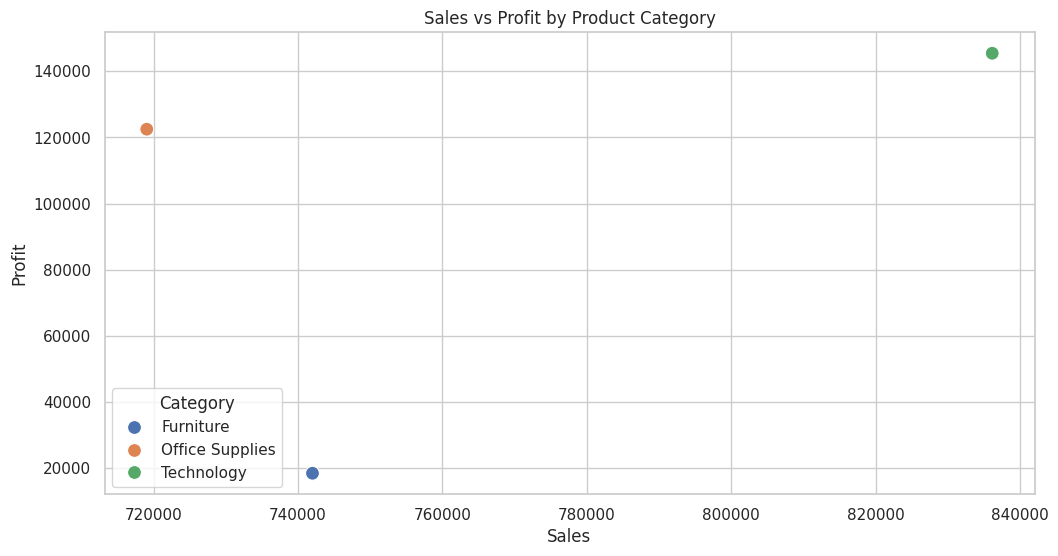

In [18]:
# Question 13: Relationship between product sales and profitability by category
category_metrics = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
sns.scatterplot(data=category_metrics, x='Sales', y='Profit', hue='Category', s=100)
plt.title('Sales vs Profit by Product Category')
plt.show()


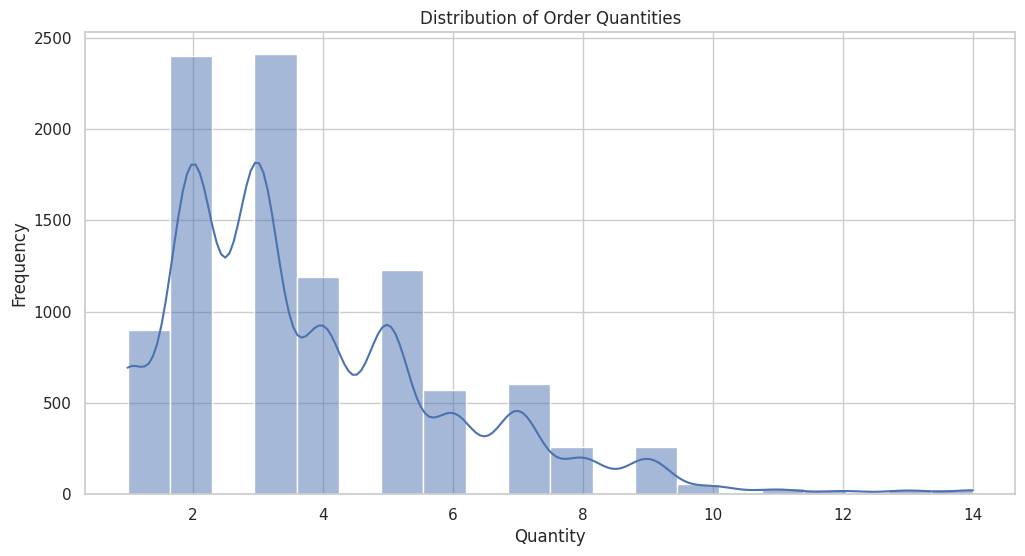

In [19]:
# Question 14: Distribution of order quantities for products
sns.histplot(df['Quantity'], bins=20, kde=True)
plt.title('Distribution of Order Quantities')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

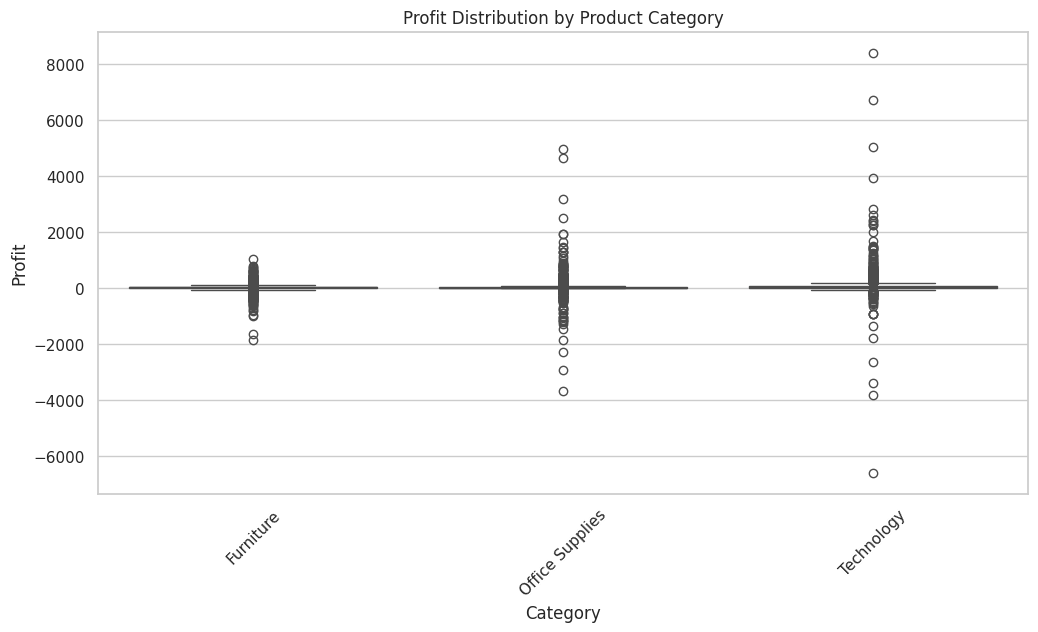

In [20]:
# Question 15: Profit distributions across different product categories
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Product Category')
plt.xticks(rotation=45)
plt.show()

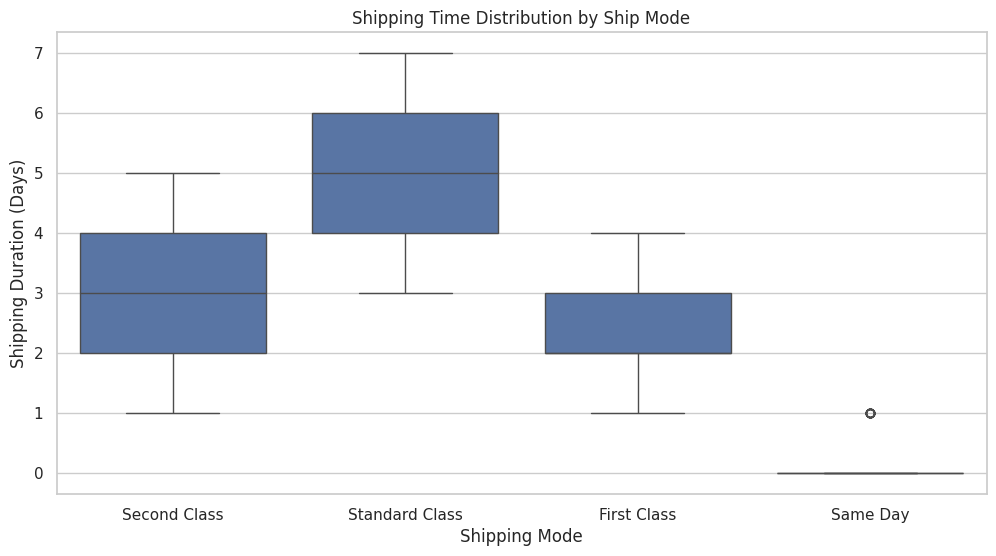

In [21]:
# Question 16: Shipping time distributions for different shipping modes
df['Ship Time'] = (df['Ship Date'] - df['Order Date']).dt.days
sns.boxplot(data=df, x='Ship Mode', y='Ship Time')
plt.title('Shipping Time Distribution by Ship Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Shipping Duration (Days)')
plt.show()

<ipython-input-22-f1cfd37170d4>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = df.set_index('Order Date').resample('M')['Order ID'].nunique()


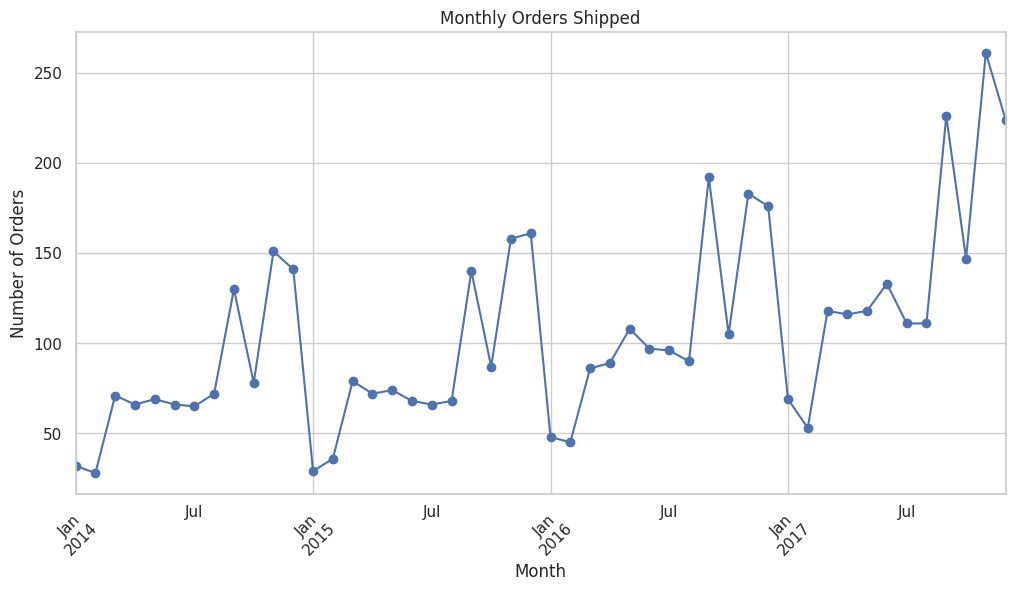

In [22]:
# Question 17: Monthly trend in the number of orders shipped
monthly_orders = df.set_index('Order Date').resample('M')['Order ID'].nunique()
monthly_orders.plot(marker='o', title='Monthly Orders Shipped')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

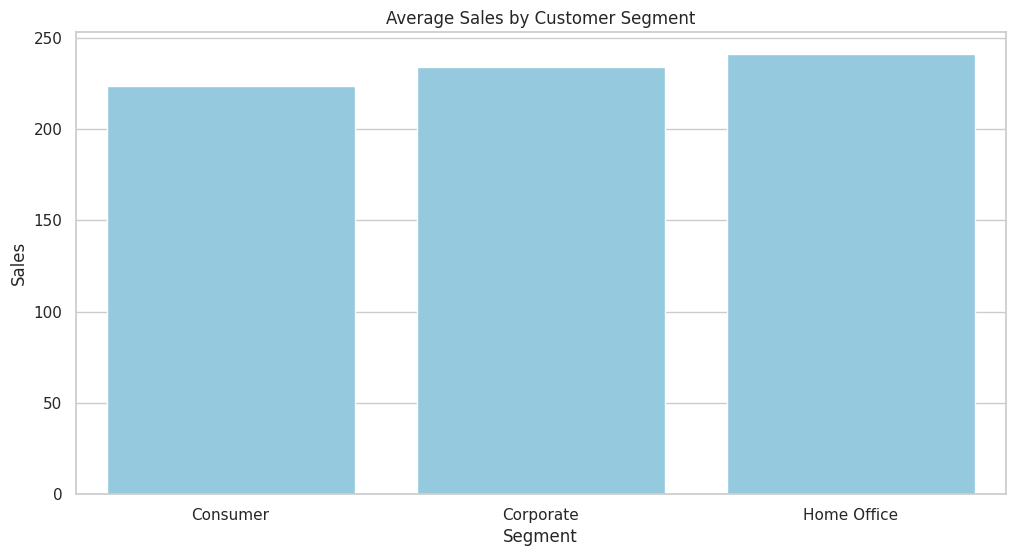

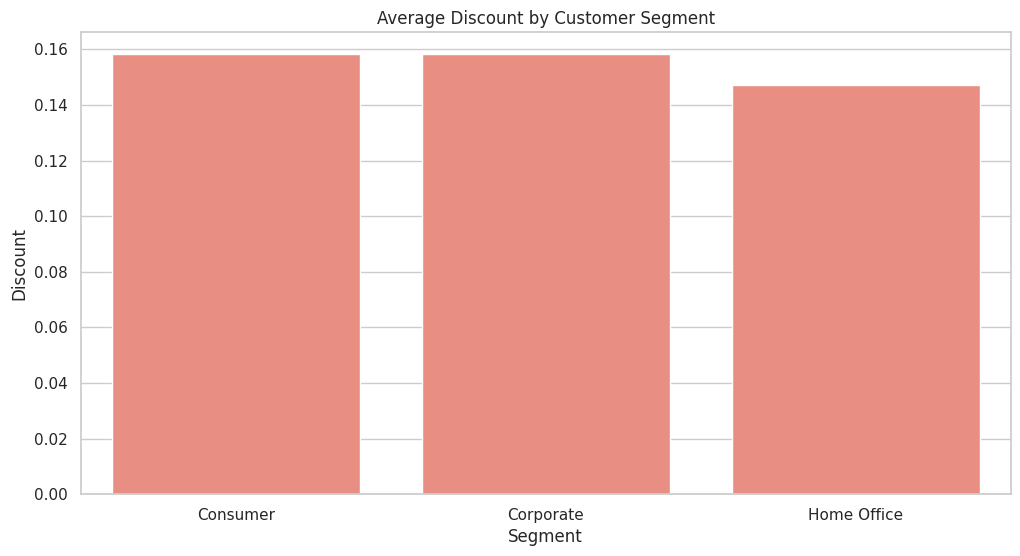

In [23]:
# Question 18: Sales and discount rates by customer segments
segment_summary = df.groupby('Segment')[['Sales', 'Discount']].mean().reset_index()
sns.barplot(data=segment_summary, x='Segment', y='Sales', color='skyblue')
plt.title('Average Sales by Customer Segment')
plt.show()
sns.barplot(data=segment_summary, x='Segment', y='Discount', color='salmon')
plt.title('Average Discount by Customer Segment')
plt.show()

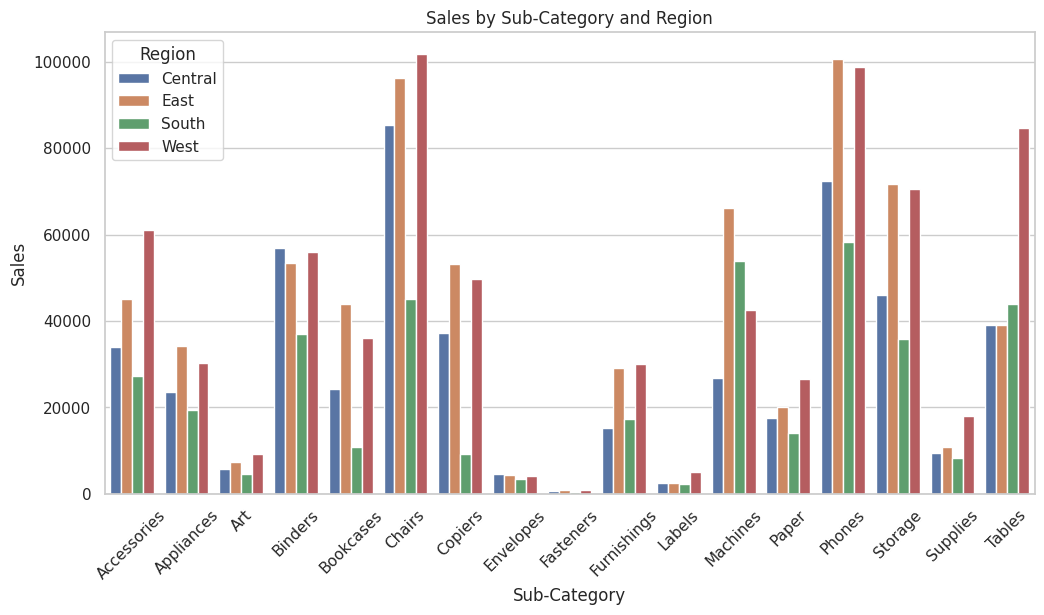

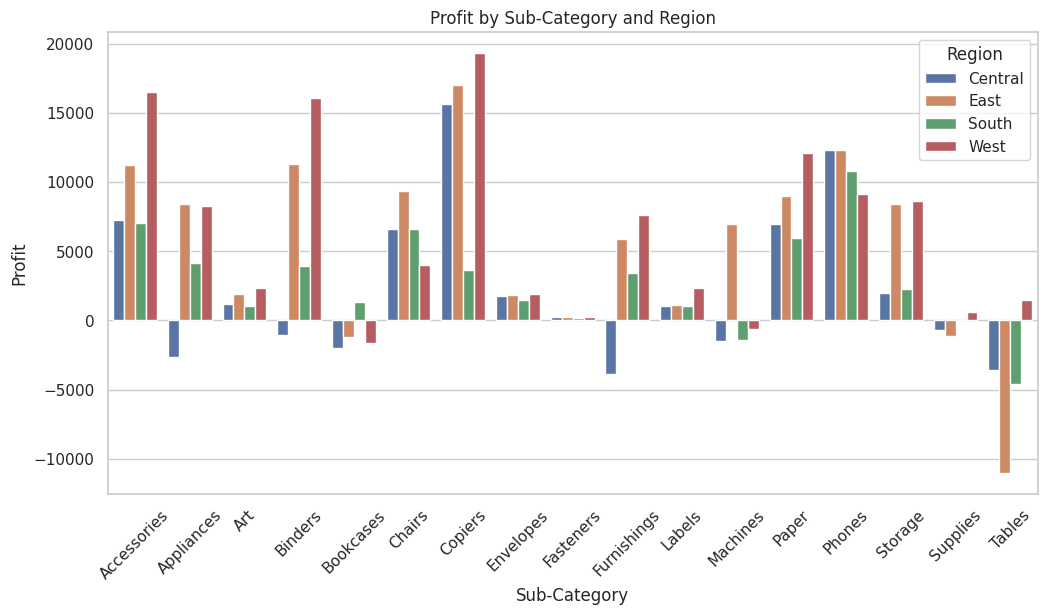

In [24]:
# Question 19: Sales and profit trends by subcategory and region
subcategory_region = df.groupby(['Sub-Category', 'Region'])[['Sales', 'Profit']].sum().reset_index()
sns.barplot(data=subcategory_region, x='Sub-Category', y='Sales', hue='Region')
plt.title('Sales by Sub-Category and Region')
plt.xticks(rotation=45)
plt.show()
sns.barplot(data=subcategory_region, x='Sub-Category', y='Profit', hue='Region')
plt.title('Profit by Sub-Category and Region')
plt.xticks(rotation=45)
plt.show()

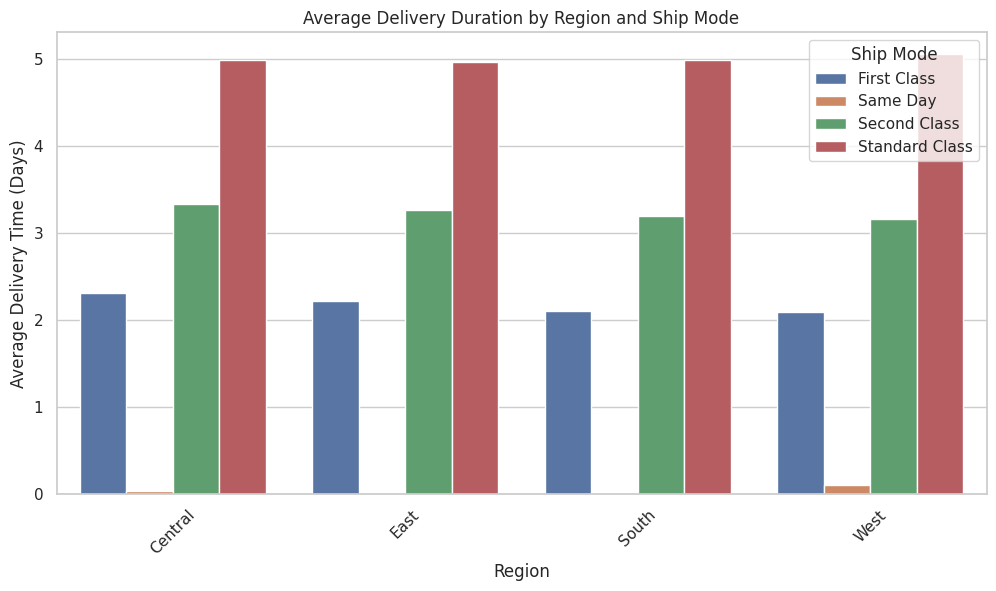

In [25]:
# Question 20: Average delivery duration by region and ship mode
avg_delivery = df.groupby(['Region', 'Ship Mode'])['Ship Time'].mean().reset_index()
sns.barplot(data=avg_delivery, x='Region', y='Ship Time', hue='Ship Mode')
plt.title('Average Delivery Duration by Region and Ship Mode')
plt.xticks(rotation=45)
plt.ylabel('Average Delivery Time (Days)')
plt.show()

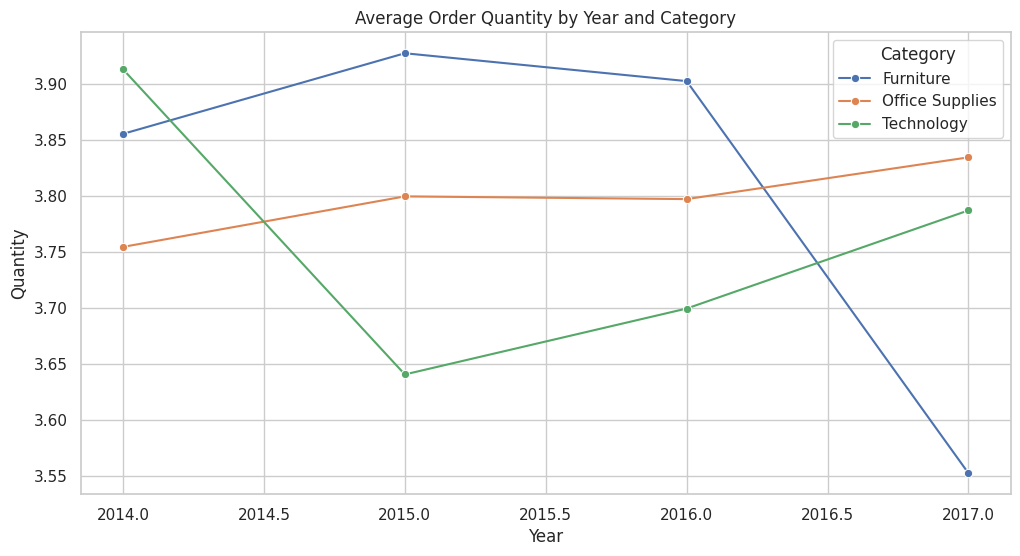

In [26]:
# Question 21: Average order quantity over the years by category
df['Year'] = df['Order Date'].dt.year
avg_quantity = df.groupby(['Year', 'Category'])['Quantity'].mean().reset_index()
sns.lineplot(data=avg_quantity, x='Year', y='Quantity', hue='Category', marker='o')
plt.title('Average Order Quantity by Year and Category')
plt.show()

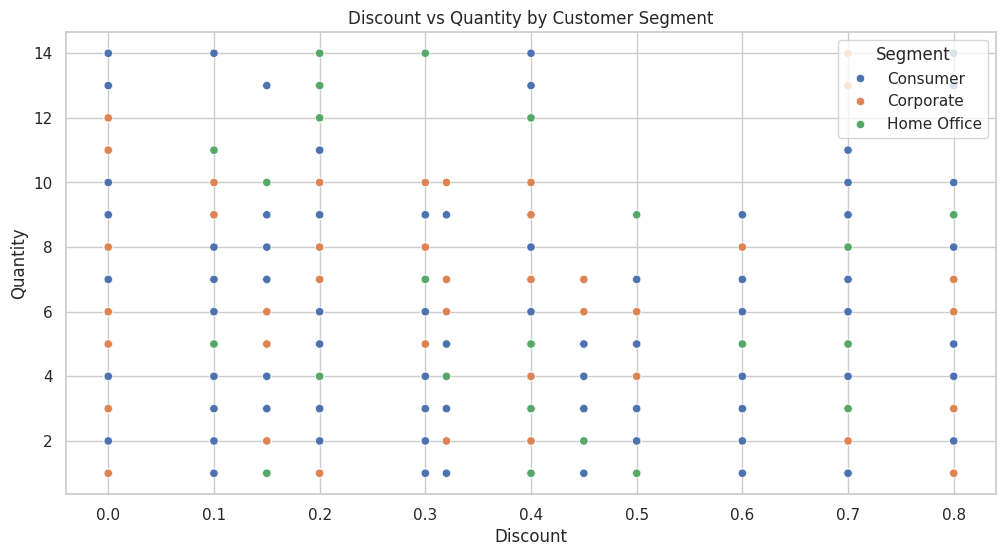

In [27]:
# Question 22: Correlation between discount and quantity by segment
sns.scatterplot(data=df, x='Discount', y='Quantity', hue='Segment')
plt.title('Discount vs Quantity by Customer Segment')
plt.show()

In [28]:
# Question 23: Proportion of returned orders by region (assumes returns marked in Remarks)
if 'Returned' in df.columns:
    returned = df[df['Returned'] == 'Yes']
    returns_by_region = returned.groupby('Region')['Order ID'].nunique() / df.groupby('Region')['Order ID'].nunique()
    returns_by_region.plot(kind='bar', title='Return Rate by Region')
    plt.ylabel('Return Proportion')
    plt.show()
else:
    print("Column for returns not found in dataset.")

Column for returns not found in dataset.


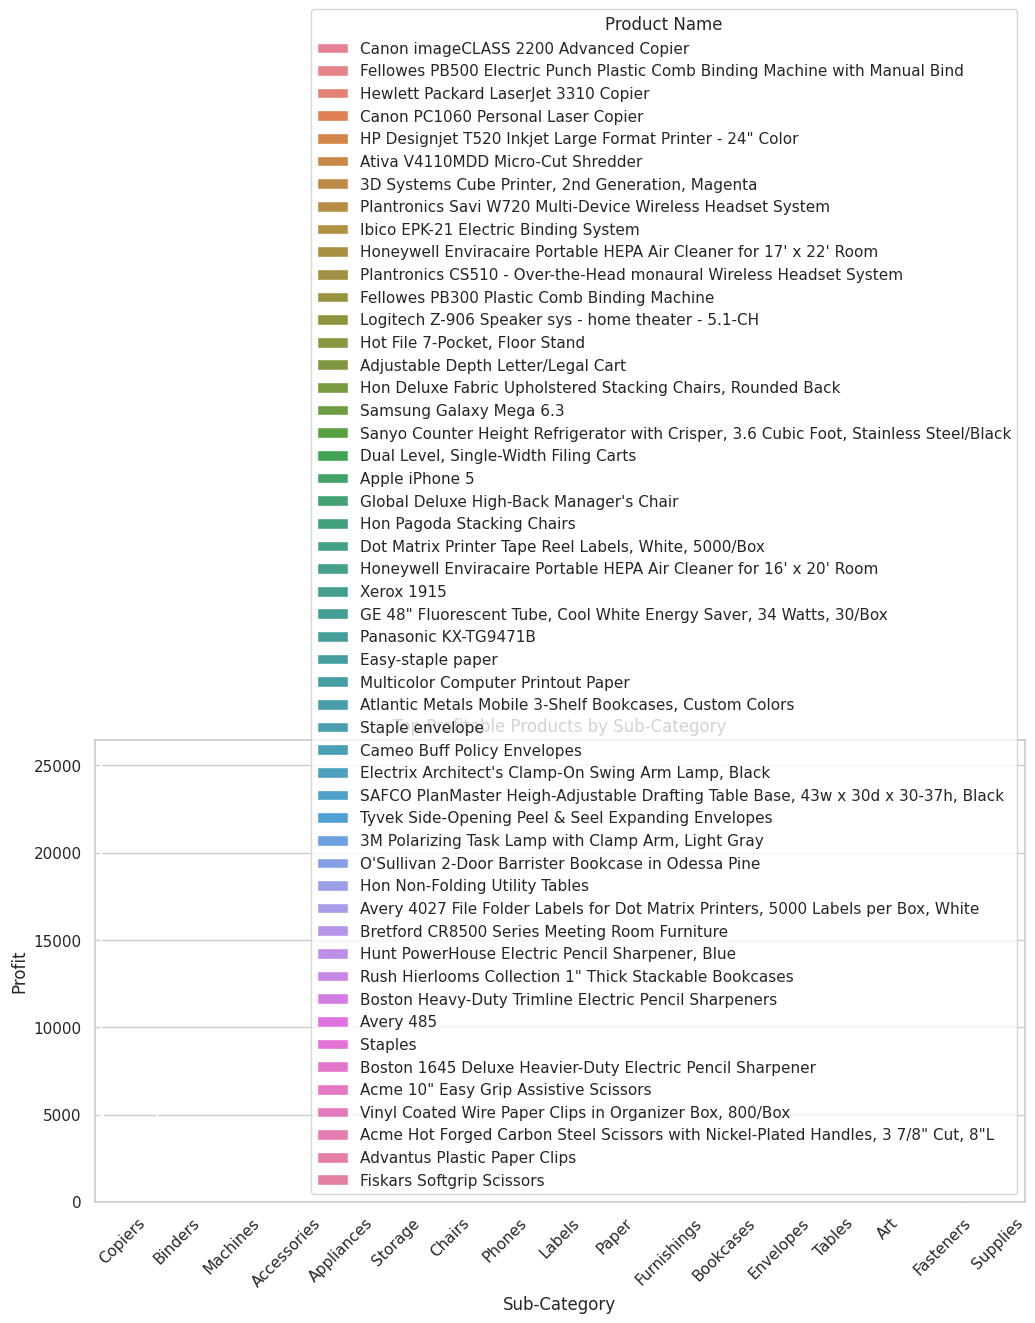

In [29]:
# Question 24: Profit of products by subcategory
product_profit = df.groupby(['Sub-Category', 'Product Name'])['Profit'].sum().reset_index()
top_products = product_profit.sort_values(by='Profit', ascending=False).groupby('Sub-Category').head(3)
sns.barplot(data=top_products, x='Sub-Category', y='Profit', hue='Product Name')
plt.title('Top Profitable Products by Sub-Category')
plt.xticks(rotation=45)
plt.show()

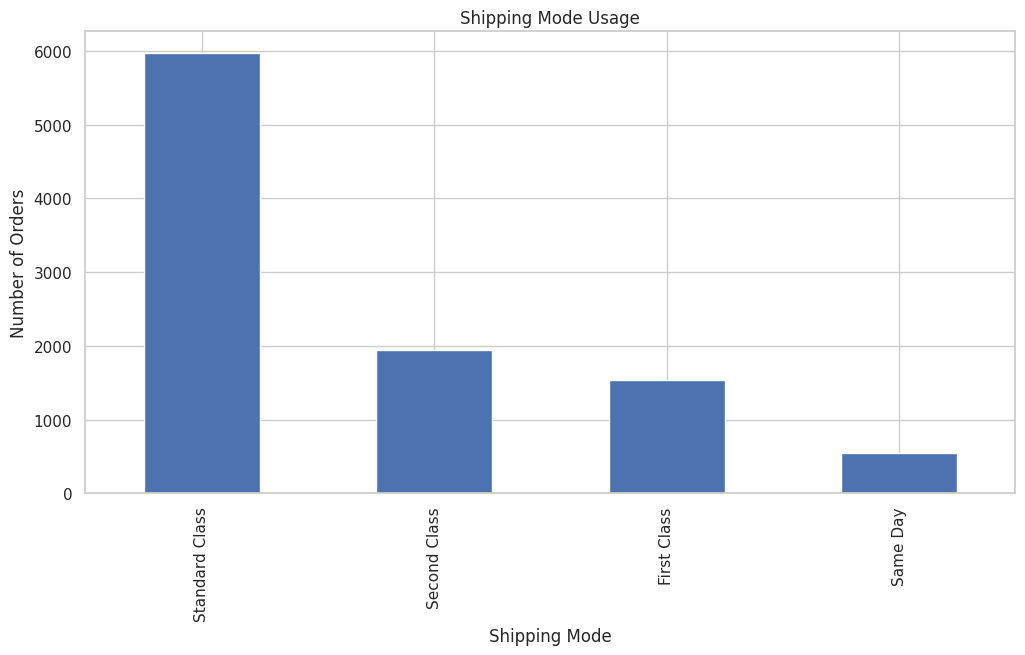

In [30]:
# Question 25: Most commonly used shipping mode
ship_mode_counts = df['Ship Mode'].value_counts()
ship_mode_counts.plot(kind='bar', title='Shipping Mode Usage')
plt.ylabel('Number of Orders')
plt.xlabel('Shipping Mode')
plt.show()

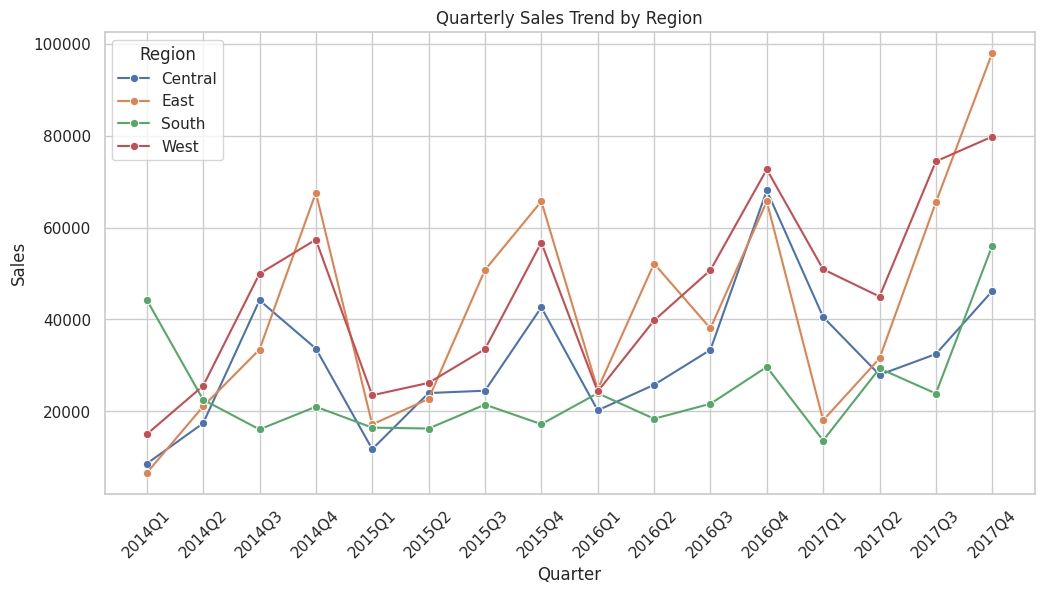

In [31]:
# Question 26: Regional sales trend by quarter
df['Quarter'] = df['Order Date'].dt.to_period('Q')
quarterly_sales = df.groupby(['Quarter', 'Region'])['Sales'].sum().reset_index()
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].astype(str)
sns.lineplot(data=quarterly_sales, x='Quarter', y='Sales', hue='Region', marker='o')
plt.title('Quarterly Sales Trend by Region')
plt.xticks(rotation=45)
plt.show()

In [36]:
# Question 27: Distribution of order priorities across product categories
# Assuming 'Order Priority' is the correct column name or is available in the DataFrame
# If the column has a different name, replace 'Order Priority' with the actual name
if 'Order Priority' in df.columns:
    priority_category = df.groupby(['Category', 'Order Priority'])['Order ID'].count().reset_index()
    sns.barplot(data=priority_category, x='Category', y='Order ID', hue='Order Priority')
    plt.title('Order Priority Distribution by Category')
    plt.ylabel('Number of Orders')
    plt.show()
else:
    print("Column 'Order Priority' not found in the dataset. Please check the column name or data.")

Column 'Order Priority' not found in the dataset. Please check the column name or data.


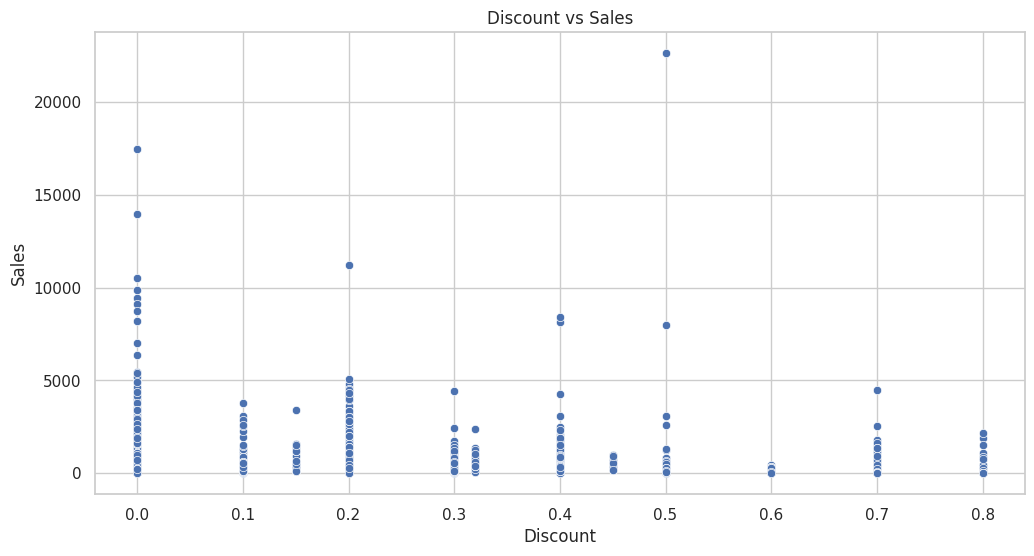

In [33]:
# Question 28: Relationship between discounts and sales
sns.scatterplot(data=df, x='Discount', y='Sales')
plt.title('Discount vs Sales')
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.show()

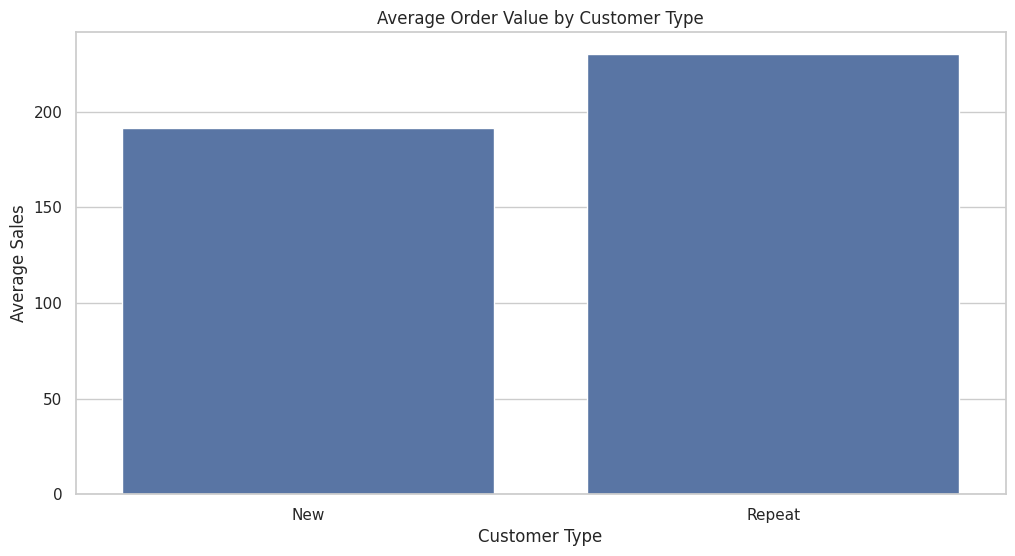

In [34]:
# Question 29: Average order value by customer type (Repeat vs New)
customer_order_counts = df.groupby('Customer ID')['Order ID'].nunique()
df['Customer Type'] = df['Customer ID'].apply(lambda x: 'Repeat' if customer_order_counts[x] > 1 else 'New')
order_value = df.groupby('Customer Type')['Sales'].mean().reset_index()
sns.barplot(data=order_value, x='Customer Type', y='Sales')
plt.title('Average Order Value by Customer Type')
plt.ylabel('Average Sales')
plt.show()

In [35]:
# Question 30: Geographical distribution of returns and impact on profitability
# Placeholder if return info is available
if 'Returned' in df.columns:
    returns_profit = df[df['Returned'] == 'Yes'].groupby('Region')['Profit'].sum()
    returns_profit.plot(kind='bar', color='red', title='Profit Loss from Returns by Region')
    plt.ylabel('Total Lost Profit')
    plt.show()
else:
    print("Column for returns not found in dataset.")

Column for returns not found in dataset.
